# Reconstruction error across the whole campaign

`part_1` (`reconstruction_local`) inspects two named models spectrum by spectrum. This
notebook is its population-level counterpart: every ready model, summarized rather than
inspected, so a model that looks fine on the handful of cases `part_1` draws is checked
against the full evaluation sample before that impression is trusted.

## Introduction

Three questions are asked, at the level of the whole campaign rather than of individual
spectra:

- What are the reconstruction error statistics (mean, median, high quantiles) per model,
  and how do they **distribute** across pixels, not just summarize to one number?
- Does the error distribute unevenly across source images — are there tissue sections a
  model reconstructs systematically worse, hidden by a campaign-wide average?
- How does the error distribution shift under input perturbation, campaign-wide, relative
  to the baseline model — coarser than `part_1`'s per-case detail, but covering every
  ready model instead of two.

### Assumptions

- **The reconstruction cost is the Masserstein transport cost** the models are trained to
  minimize (`MassersteinLoss`), not the Euclidean norm, for the same reason `part_1`
  states it: with peaks about one bin wide, a Euclidean distance rates a one-bin
  displacement as a near-total change, which contradicts the campaign's own notion of a
  small chemical change. MSE/MAE/cosine/spectral-angle/TIC-error are also available in
  `error_distributions` (the base inference cache computes them for other purposes) but
  are not the primary quantity here.
- **Per-image grouping depends on what the dataset records.** `sample_ids` are only
  resolvable to a source-image identity for a `CohortDataset` (a merged-store
  `PixelDataset`'s plain integer ids are not resolved further here — see `part_2`'s own
  routine docstring). `per_image_identity_available` in the loaded metadata says which
  case this run is in; when it is `False`, the per-image section below reports that
  explicitly rather than fabricating a single-group breakdown.
- **The perturbation-based drift table is coarse by design.** Unlike `part_1`, no case is
  selected, no individual spectrum is displayed, and only a handful of amplitudes are
  evaluated (`global_perturbation_amplitudes`), so it scales to every ready model in the
  campaign rather than to two.

### Notation

For model $m$ and pixel $i$, $W(\hat x^m_i, x_i)$ is the Masserstein cost between that
pixel's reconstruction and input. $\bar W_m$ and $\mathrm{med}(W_m)$ denote its mean and
median over the evaluation sample. For a perturbation family and amplitude $t$,
$\mathrm{med}(W_m(t))$ is the median drift against the model's own clean reconstruction,
and the reported ratio is $\mathrm{med}(W_m(t)) / \mathrm{med}(W_{\mathrm{baseline}}(t))$.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as precompute
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("reconstruction_global")

from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import (
    load_model_catalog, load_visualization_theme, select_catalog_frame,
)


2026-09-19 19:21:10,509 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-19 19:21:10,512 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-19 19:21:10,966 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-19 19:21:10,968 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 28 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-19 19:21:10,976 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-19 19:21:10,978 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 46 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-19 19:21:10,999 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-19 19:21:11,018 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-19 19:21:11,020 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 33 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Configuration

## Producing the tables this notebook reads

### Methodology

#### Implementation

Reconstructing the evaluation sample under a coarse perturbation grid for every ready
model is minutes of GPU work; the per-pixel error table and the per-model summary are
already written by the base full-campaign inference cache and are only joined and
re-shaped here.

That work lives in `predictive_precompute.reconstruction_global`, is configured by
`analysis_settings.yaml` next to this notebook, and writes its tables to this notebook's
results directory. It requires the base inference cache
(`predictive_precompute.precompute`) to already be populated.

Run it once, detached, with the command printed below. It refuses to start on the
processor unless explicitly allowed. The command is generated by the runner itself, so
the instruction cannot drift from the entry point it describes.

Everything after this section reads those tables, which is why re-running this notebook
takes seconds.

### Remarks

### Notes

In [2]:
from msi_autoencoder_wrapper.analysis.precompute.cli import run_precompute_command
SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/17_09_26_metaspace_heads_vpu_contractive/analysis_settings.yaml")
ANALYSIS = "reconstruction_global"

settings = campaign.load_settings(SETTINGS_PATH)
settings["settings_path"] = str(SETTINGS_PATH)
analysis_settings = precompute.analysis_settings(settings, ANALYSIS)
ARTIFACT_DIR = analysis_settings["output_directory"]

theme = resolve_theme(None)
theme.apply()

# --- embedded figure resolution --------------------------------------------
FIGURE_RASTER_DPI = 100
plt.rcParams["savefig.dpi"] = FIGURE_RASTER_DPI
# ---------------------------------------------------------------------------

print("Run the precompute once, in the background:")
print(f"  {run_precompute_command(SETTINGS_PATH)}")
print("\nOr in the foreground, to watch it:")
print(f"  {run_precompute_command(SETTINGS_PATH, background=False)}")

Run the precompute once, in the background:
  nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings assets/experiments/autoencoder_architecture/notebooks/segmentation_model/17_09_26_metaspace_heads_vpu_contractive/analysis_settings.yaml > assets/experiments/autoencoder_architecture/notebooks/segmentation_model/17_09_26_metaspace_heads_vpu_contractive/shared_precompute.log 2>&1 &

Or in the foreground, to watch it:
  uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings assets/experiments/autoencoder_architecture/notebooks/segmentation_model/17_09_26_metaspace_heads_vpu_contractive/analysis_settings.yaml


In [3]:
# Tables produced by the command above; `load_analysis_table` reports the command again
# if one is missing, so a fresh checkout fails with an instruction rather than a stack
# trace.
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import (
    load_model_catalog, load_visualization_theme, select_catalog_frame,
)
models = load_model_catalog(settings)
summary_frame = select_catalog_frame(precompute.load_analysis_table(settings, ANALYSIS, "reconstruction_summary"), models)
error_frame = select_catalog_frame(precompute.load_analysis_table(settings, ANALYSIS, "error_distributions"), models)
image_frame = select_catalog_frame(precompute.load_analysis_table(settings, ANALYSIS, "image_breakdown"), models)
drift_frame = select_catalog_frame(precompute.load_analysis_table(settings, ANALYSIS, "perturbation_drift"), models)

provenance = precompute.load_analysis_metadata(settings, ANALYSIS)
PER_IMAGE_AVAILABLE = bool(provenance["per_image_identity_available"])

CONDITION_ORDER = (
    drift_frame.drop_duplicates("model_id")
    .sort_values(["role", "label"], key=lambda s: s if s.name != "role" else s.eq("baseline"))
    ["label"].tolist()
)
LABEL_COLOR = {label: theme.color_for_model(label, index) for index, label in enumerate(CONDITION_ORDER)}

print(f"{error_frame.model_id.nunique()} model(s) on split '{provenance['evaluation_split']}', "
     f"{len(error_frame)} pixel-level record(s)")
print(f"per-image identity available: {PER_IMAGE_AVAILABLE}")
print(f"precomputed at commit {provenance['git_commit']} on {provenance['settings']['device']}")

130 model(s) on split 'test', 546650 pixel-level record(s)
per-image identity available: False
precomputed at commit b2026c4bcdb93b4bb5ceb647ae2bbdfb06d0feef on cuda


## Reconstruction error summary across the campaign

### Methodology

#### Theoretical

A single mean hides how a distribution is shaped: two models can share a mean
reconstruction cost while one has a long tail of badly reconstructed pixels the other
does not. Mean, median and high quantiles (90th, 99th) are reported together so a
heavy tail is visible even before the distribution itself is plotted below.

#### Implementation

`mean`, `median`, `q90` and `q99` come directly from the base inference cache's
`reconstruction` table (computed once per model over the full evaluation sample), for
every reconstruction-quality metric it records; the pivot below narrows the display to
Masserstein, the primary quantity here.

#### Figure descriptions

Table: one row per model (identified by its condition `label`), columns are the four
summary statistics of the Masserstein reconstruction cost over the evaluation sample.
Sorted with the baseline first, then by ascending median cost.

### Remarks

### Notes

In [4]:
identity = drift_frame.drop_duplicates("model_id")[["model_id", "source", "role", "condition", "label"]]
masserstein_summary = (
    summary_frame.query("metric == 'masserstein' and split == @provenance['evaluation_split']")
    .pivot_table(index="label", columns="statistic", values="value")
    [["mean", "median", "q90", "q99"]]
)
# `identity` carries one row per model_id, i.e. one row per repetition — several rows
# per label. A label's role is a property of the condition, not the repetition, so
# `.drop_duplicates("label")` first avoids indexing into a duplicated-label Series
# (which `.get(label, False)` cannot resolve to a scalar).
is_baseline = identity.drop_duplicates("label").set_index("label").role.eq("baseline")
masserstein_summary = masserstein_summary.loc[
    sorted(masserstein_summary.index, key=lambda label: (not is_baseline.get(label, False), masserstein_summary.loc[label, "median"]))
]
display(masserstein_summary.round(5))

statistic,mean,median,q90,q99
label,,,,
vpu + contrastive,3.27385,2.75624,5.45604,9.92405
vpu,3.38306,2.83839,5.70804,10.45617
"VPU + contrastive (T=0.07, w=0.01)",3.22001,2.66244,5.43910,10.38757
"VPU + contrastive (T=0.01, w=0.001)",3.19451,2.67160,5.33775,10.14097
"VPU + contrastive (T=0.01, w=0.1)",3.21934,2.69740,5.34586,9.95134
"VPU + contrastive (T=0.15, w=0.001)",3.27874,2.71644,5.61040,10.18910
"VPU + contractive + contrastive (T=0.15, w=0.001)",3.26694,2.72864,5.48214,10.44624
"VPU + contrastive (T=0.30, w=0.01)",3.27392,2.73869,5.48642,10.24870
"VPU + contrastive (T=0.30, w=0.1)",3.30553,2.74091,5.61638,10.62476


## Distribution of reconstruction error across models

### Methodology

#### Theoretical

The summary above is exactly the kind of aggregate that can hide a heavy tail; this
section shows the full per-pixel distribution instead, one violin per model, so a wide
violin or a long upper whisker is visible directly rather than inferred from `q99`
alone.

#### Implementation

Every pixel in the evaluation sample contributes one value; the violins use all of
them, with a seeded, fixed-size subsample overlaid as points (one point per pixel is
unreadable at campaign scale).

#### Figure descriptions

One violin per model, ordered as in the summary table above (baseline first, then
ascending median), x-axis the condition label, y-axis the per-pixel Masserstein
reconstruction cost on a logarithmic scale. Overlaid points are a fixed random
subsample of the pixels behind that violin, not the complete sample.

### Remarks

### Notes

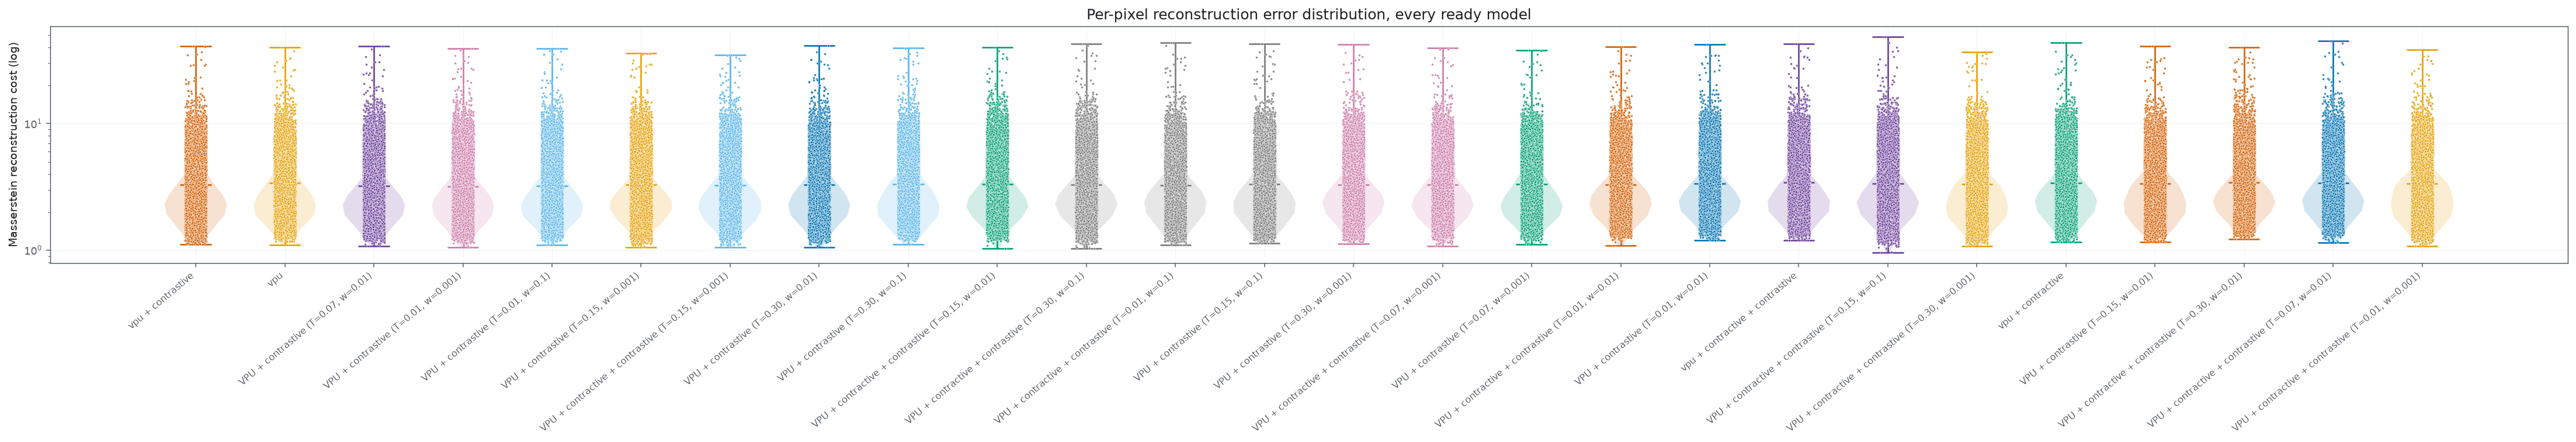

In [5]:
# --- what this figure shows -------------------------------------------------
POINT_SAMPLE = 300       # points overlaid per violin; the violin uses every pixel
# ---------------------------------------------------------------------------
point_rng = np.random.default_rng(int(settings["sample_seed"]) + 21)

ordered_labels = list(masserstein_summary.index)

figure, axis = plt.subplots(figsize=(1.1 * len(ordered_labels) + 3.0, 5.5), dpi=theme.figure_dpi)
for position, label in enumerate(ordered_labels):
    values = error_frame.query("label == @label")["masserstein"].to_numpy()
    values = values[np.isfinite(values) & (values > 0)]
    if not len(values):
        continue
    plot_violin_with_points(values, position=position, ax=axis, width=0.7, color=LABEL_COLOR[label],
                            point_size=4.0, jitter=0.12, theme=theme)
axis.set_yscale("log")
axis.set_xticks(range(len(ordered_labels)))
axis.set_xticklabels(ordered_labels, rotation=40, ha="right", fontsize=8)
axis.set(ylabel="Masserstein reconstruction cost (log)", title="Per-pixel reconstruction error distribution, every ready model")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

## Reconstruction error by source image

### Methodology

#### Theoretical

A campaign-wide average can be driven by a single badly reconstructed tissue section
while every other image is handled well, or the reverse: uniformly mediocre
reconstruction with no single outlier. Distinguishing the two matters for how a
regression is diagnosed, and neither is visible in the pooled distribution above.

#### Implementation

Per-pixel Masserstein cost is grouped by `image_key`, resolved from the materialized
split's own `sample_ids` (see `reconstruction_global`'s docstring for exactly which
dataset shapes this is available for). When unavailable, this section reports that
explicitly instead of drawing a single-group figure that would look like a
per-image breakdown without being one.

#### Figure descriptions

When available: one point per (model, image) pair, x-axis the model's condition label,
y-axis the per-image mean Masserstein cost, colored by image. A model whose points
spread widely across images has uneven, image-dependent reconstruction quality; one
whose points cluster is uniform. The printed table adds, per model, the range between
its best- and worst-reconstructed image as a fraction of its own campaign-wide mean —
the statistic asked for: how strongly the per-image means differ.

### Remarks

### Notes

In [6]:
if not PER_IMAGE_AVAILABLE:
    print("No source-image identity is available for this dataset/configuration "
         "(per_image_identity_available=False in the precomputed metadata) — this "
         "section is intentionally left without a figure rather than showing a "
         "single fabricated group.")
else:
    figure, axis = plt.subplots(figsize=(1.1 * len(ordered_labels) + 3.0, 5.5), dpi=theme.figure_dpi)
    for position, label in enumerate(ordered_labels):
        model_ids = identity.query("label == @label").model_id
        rows = image_frame[image_frame.model_id.isin(model_ids)]
        jitter = point_rng.normal(0.0, 0.06, size=len(rows))
        axis.scatter(position + jitter, rows["mean_masserstein"], s=30, alpha=0.8,
                     color=LABEL_COLOR[label], edgecolor="white", linewidth=0.4)
    axis.set_xticks(range(len(ordered_labels)))
    axis.set_xticklabels(ordered_labels, rotation=40, ha="right", fontsize=8)
    axis.set(ylabel="per-image mean Masserstein cost", title="Reconstruction error per source image, by model")
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
    figure.tight_layout()

    # `image_frame` already carries `label` (assigned inside the precompute routine),
    # so no re-merge with `identity` is needed here.
    spread = (
        image_frame.groupby("label")["mean_masserstein"]
        .agg(worst_image="max", best_image="min", campaign_mean="mean")
    )
    spread["spread_over_campaign_mean"] = (spread["worst_image"] - spread["best_image"]) / spread["campaign_mean"]
    display(spread.loc[ordered_labels].round(4))

No source-image identity is available for this dataset/configuration (per_image_identity_available=False in the precomputed metadata) — this section is intentionally left without a figure rather than showing a single fabricated group.


## Distribution shift under perturbation, against baseline

### Methodology

#### Theoretical

`part_1` shows this in full detail for two models; here every ready model is checked at
a coarse amplitude grid, so a robustness effect visible only in the two models `part_1`
happened to compare (or absent from them) can be told apart from a campaign-wide
pattern.

#### Implementation

For every ready model, the same shared evaluation sample and the same perturbation
targets (identical noise draws across models) are used, at `global_perturbation_amplitudes`
amplitudes — coarser than `part_1`'s full curve. `times_baseline` is each model's median
drift divided by the `baseline` role's own median drift at the same perturbation family
and amplitude; at amplitude 0 this is the undefined 0/0 for the baseline itself and is
left `NaN` by construction, not an error.

#### Figure descriptions

Table: one row per (model, perturbation, amplitude), with the median Masserstein drift
against the model's own clean reconstruction and its ratio to the baseline's. A
`verdict` column categorizes that ratio at the largest configured amplitude:
`much_worse`/`worse`/`comparable`/`better`/`much_better`, using ±20%/±50% as the
comparable/notable/large thresholds — an explicit, named choice, not a hidden literal.

### Remarks

### Notes

perturbation,additive_noise,intensity_lognormal,mz_shift,width_jitter
label,,,,
"VPU + contractive + contrastive (T=0.01, w=0.001)",1.016,0.985,0.833,0.913
"VPU + contractive + contrastive (T=0.01, w=0.01)",1.021,0.989,0.903,0.941
"VPU + contractive + contrastive (T=0.01, w=0.1)",1.023,0.980,0.734,0.759
"VPU + contractive + contrastive (T=0.07, w=0.001)",1.029,0.992,0.772,0.827
"VPU + contractive + contrastive (T=0.07, w=0.01)",1.034,0.973,0.940,0.798
"VPU + contractive + contrastive (T=0.15, w=0.001)",1.032,0.997,0.819,0.824
"VPU + contractive + contrastive (T=0.15, w=0.01)",1.020,0.997,0.776,0.785
"VPU + contractive + contrastive (T=0.15, w=0.1)",1.022,0.971,0.890,0.782
"VPU + contractive + contrastive (T=0.30, w=0.001)",1.025,0.993,0.829,0.850


perturbation,additive_noise,intensity_lognormal,mz_shift,width_jitter
label,,,,
"VPU + contractive + contrastive (T=0.01, w=0.001)",comparable,comparable,comparable,comparable
"VPU + contractive + contrastive (T=0.01, w=0.01)",comparable,comparable,comparable,comparable
"VPU + contractive + contrastive (T=0.01, w=0.1)",comparable,comparable,better,comparable
"VPU + contractive + contrastive (T=0.07, w=0.001)",comparable,comparable,better,comparable
"VPU + contractive + contrastive (T=0.07, w=0.01)",comparable,comparable,comparable,better
"VPU + contractive + contrastive (T=0.15, w=0.001)",comparable,comparable,better,better
"VPU + contractive + contrastive (T=0.15, w=0.01)",comparable,comparable,better,comparable
"VPU + contractive + contrastive (T=0.15, w=0.1)",comparable,comparable,worse,comparable
"VPU + contractive + contrastive (T=0.30, w=0.001)",comparable,comparable,comparable,better


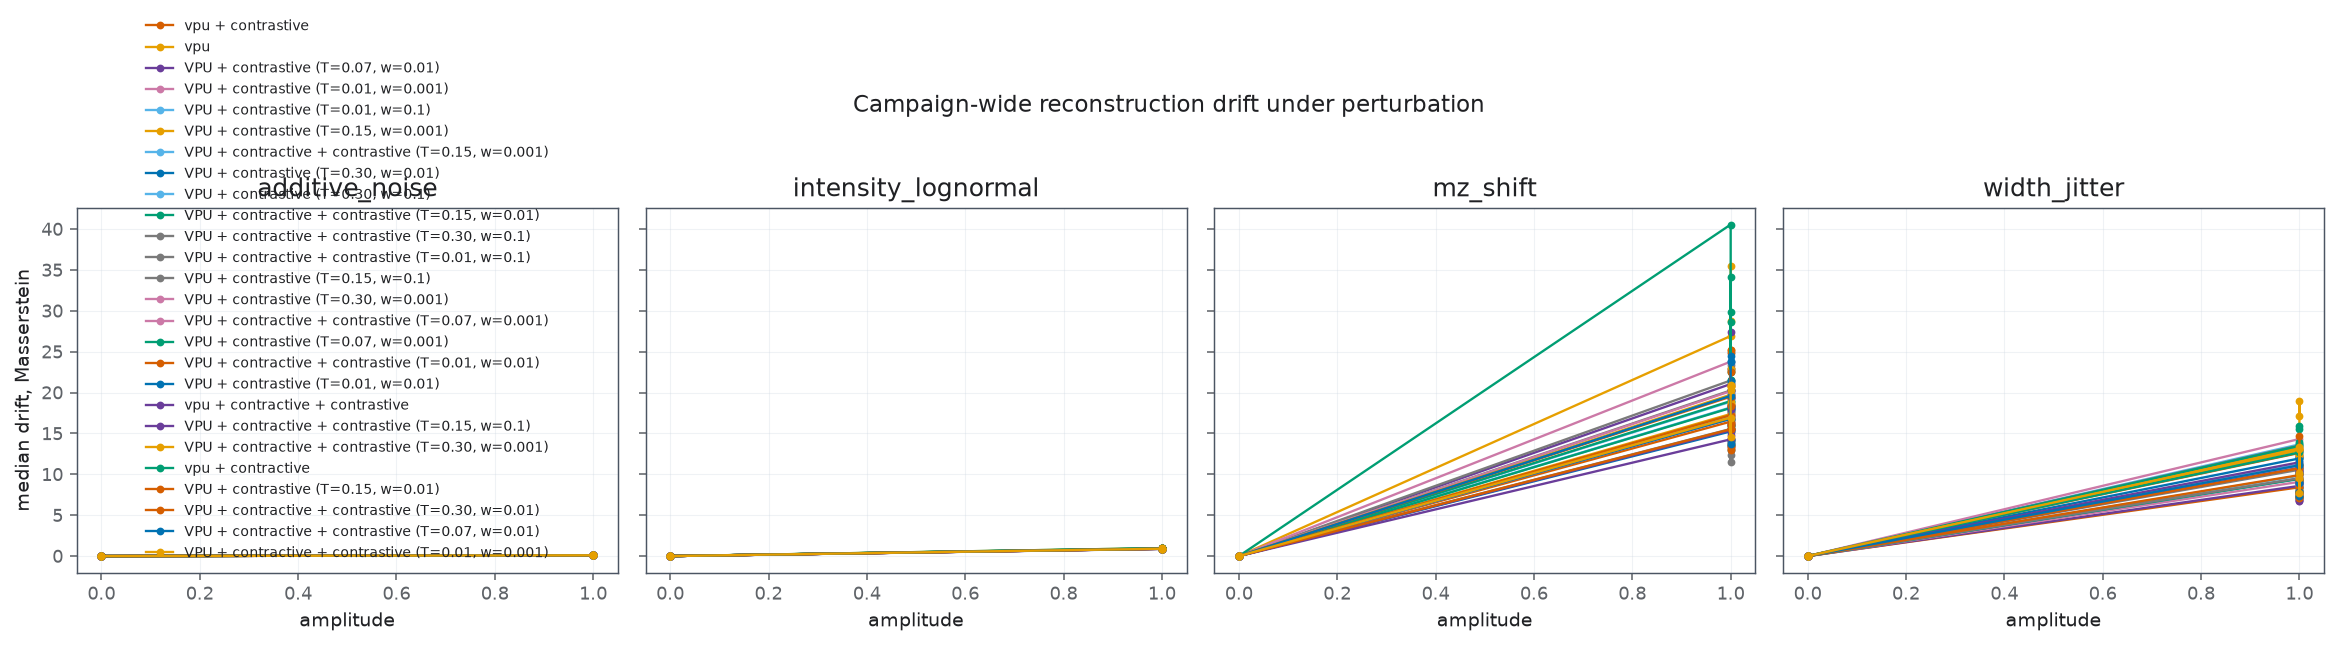

In [7]:
# --- what this table and figure show ----------------------------------------
LARGEST_AMPLITUDE = drift_frame.amplitude.max()   # the "much worse/better" verdict is read here
NOTABLE_THRESHOLD = 0.20                          # ratio deviation from 1.0 counted as "worse"/"better"
LARGE_THRESHOLD = 0.50                            # ratio deviation from 1.0 counted as "much_worse"/"much_better"
# ---------------------------------------------------------------------------


def verdict(ratio: float) -> str:
    if not np.isfinite(ratio):
        return "n/a"
    deviation = ratio - 1.0
    if deviation > LARGE_THRESHOLD:
        return "much_worse"
    if deviation > NOTABLE_THRESHOLD:
        return "worse"
    if deviation < -LARGE_THRESHOLD:
        return "much_better"
    if deviation < -NOTABLE_THRESHOLD:
        return "better"
    return "comparable"


at_largest = drift_frame.query("amplitude == @LARGEST_AMPLITUDE").copy()
at_largest["verdict"] = at_largest["times_baseline"].map(verdict)
display(at_largest.pivot_table(index="label", columns="perturbation", values="times_baseline").round(3))
display(at_largest.pivot_table(index="label", columns="perturbation", values="verdict", aggfunc="first"))

figure, axes = plt.subplots(1, drift_frame.perturbation.nunique(),
                            figsize=(4.2 * drift_frame.perturbation.nunique(), 4.2), dpi=theme.figure_dpi, sharey=True)
for axis, (name, family) in zip(np.atleast_1d(axes), drift_frame.groupby("perturbation")):
    for label in ordered_labels:
        run = family[family.label == label].sort_values("amplitude")
        axis.plot(run["amplitude"], run["median_drift_masserstein"], color=LABEL_COLOR[label],
                 marker="o", markersize=3, linewidth=1.2, label=label)
    axis.set(xlabel="amplitude", title=name, ylabel="median drift, Masserstein" if axis is np.atleast_1d(axes)[0] else "")
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
np.atleast_1d(axes)[0].legend(fontsize=7, frameon=theme.legend_frame)
figure.suptitle("Campaign-wide reconstruction drift under perturbation", y=1.03, fontsize=12)
figure.tight_layout()

## Reproducible artifacts

### Methodology

#### Implementation

The measured tables and their provenance are written by the precompute runner, not
here. Provenance, including the commit, the device, the seeds and the source hashes of
the analysis modules, lives in the runner's `metadata.json`.

The results directory is deliberately not versioned: it is regenerable from the runner
and its recorded provenance.

### Remarks

### Notes

In [8]:
print("precomputed tables present:", sorted(path.name for path in ARTIFACT_DIR.glob("*.csv")))
print("provenance:", {"analysis": provenance["analysis"], "git_commit": provenance["git_commit"],
                      "device": provenance["settings"]["device"], "evaluation_split": provenance["evaluation_split"],
                      "per_image_identity_available": PER_IMAGE_AVAILABLE, "models": provenance["models"]})

precomputed tables present: ['error_distributions.csv', 'image_breakdown.csv', 'perturbation_drift.csv', 'reconstruction_summary.csv']
provenance: {'analysis': 'reconstruction_global', 'git_commit': 'b2026c4bcdb93b4bb5ceb647ae2bbdfb06d0feef', 'device': 'cuda', 'evaluation_split': 'test', 'per_image_identity_available': False, 'models': 130}


## Results / Summary

### LLM

Not yet run against the real campaign cache. This notebook has not been executed
against `data/kidney_workspace`; run the base inference cache and then this analysis's
precompute command printed above, then write this section from the actually observed
summary statistics, per-image spread (if available for this dataset) and drift verdicts
before treating any interpretation here as verified.

### Person